# Corpus Profile

Profile of the 52,947 documents of the corpus (Section III-A): publication years, source titles, language of titles and abstracts (`langdetect`, seeded), author and index keywords per record, and non-English residue in the generated keywords.

Private input: `corpus_insumo_DEFINITIVO.csv`, read from `FTTS_PRIVATE_DIR` (default: the parent directory of the repository). Public inputs: `EID_KEYWORDS.xlsx`, `data/insumo_row_to_eid.csv`. Outputs in `results/e6_corpus_profile/`; only aggregates are written.

In [1]:
# ============================================================
# CONFIGURATION AND IMPORTS
# ============================================================
import os
os.environ["OMP_NUM_THREADS"] = "4"          # several notebooks run concurrently on one machine
import sys
sys.path.insert(0, "scripts")
import json
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

import common as C
from inspec_evaluation import normalize_phrase
from langdetect import DetectorFactory

DetectorFactory.seed = C.SEED                 # langdetect is stochastic unless seeded

OUT = Path("results/e6_corpus_profile")
OUT.mkdir(parents=True, exist_ok=True)

PATH_INSUMO = C.PRIVATE_DIR / "corpus_insumo_DEFINITIVO.csv"   # private (Elsevier licence)
PATH_KEYWORDS = Path("EID_KEYWORDS.xlsx")                       # published generated keywords
PATH_ALIGNMENT = Path("data/insumo_row_to_eid.csv")             # record row -> Scopus EID

SPANISH_STOP = {"de", "la", "el", "en", "y", "para", "del", "las", "los", "con", "una", "un", "por"}

if not PATH_INSUMO.exists():
    raise FileNotFoundError(
        f"Private record file not found: {PATH_INSUMO}. Set FTTS_PRIVATE_DIR to the directory "
        "holding corpus_insumo_DEFINITIVO.csv (Scopus records, not redistributed).")


def detect(text: str, n: int = 1000) -> str:
    """Language of the first n characters; strings under 20 characters are not classified."""
    from langdetect import detect as _detect
    t = str(text).strip()[:n]
    if len(t) < 20:
        return "too_short"
    try:
        return _detect(t)
    except Exception:
        return "undetermined"


T = C.Timer()
meta = C.env_metadata(
    experiment="E6 corpus profile",
    inputs={"insumo": {"path": str(PATH_INSUMO), "sha256": C.sha256(PATH_INSUMO), "redistributed": False},
            "keywords": {"path": str(PATH_KEYWORDS), "sha256": C.sha256(PATH_KEYWORDS)}},
    llm_calls=0, paid_api_calls=0)
print(json.dumps({k: meta[k] for k in ("python", "platform", "machine", "cpu_count", "git_commit")}, indent=2))
print("packages:", json.dumps(meta["packages"]))
print("inputs:", json.dumps(meta["inputs"], indent=2))

/home/mat/academic-writing/papers/from_text_to_structure/data_repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{
  "python": "3.12.3",
  "platform": "Linux-7.0.0-31-generic-x86_64-with-glibc2.39",
  "machine": "x86_64",
  "cpu_count": 16,
  "git_commit": "af664fad8d65723998851025c9d052e9bf1fa73e"
}
packages: {"numpy": "2.1.3", "pandas": "2.2.3", "scipy": "1.15.3", "sklearn": "1.9.0", "networkx": "3.6.1", "community": "0.16", "sentence_transformers": "5.1.1", "torch": "2.8.0+cpu", "transformers": "4.57.6", "langdetect": "unknown", "openai": "1.107.2"}
inputs: {
  "insumo": {
    "path": "/home/mat/academic-writing/papers/from_text_to_structure/corpus_insumo_DEFINITIVO.csv",
    "sha256": "597d4d8d44ddea693d4386798ea0a9d3380d1314782e937843e3184d78e2f274",
    "redistributed": false
  },
  "keywords": {
    "path": "EID_KEYWORDS.xlsx",
    "sha256": "a440b7cedabea950ddb0be27610e1a58f747191ae08999801d73994f9d801c8c"
  }
}


In [2]:
# ============================================================
# LOAD AND PARSE THE PRIVATE RECORDS (gate: every record has >= 6 fields)
# ============================================================
ins = pd.read_csv(PATH_INSUMO)["insumo"].astype(str).tolist()
recs_all = pd.DataFrame([C.parse_record(s) for s in ins])
# The corpus of the manuscript is the 52,947 documents with a published output (one record row per EID).
# The private file also holds 183 rows discarded at parsing (duplicated identifier or no valid output); they are
# counted here for information and excluded from every statistic below.
align_rows = C.load_alignment(PATH_ALIGNMENT, one_row_per_eid=True).insumo_row.to_numpy()
recs = recs_all.iloc[align_rows].reset_index(drop=True)
print(f"Rows in the private record file: {len(recs_all):,}  |  documents of the corpus (published output): {len(recs):,}  |  "
      f"rows discarded at parsing: {len(recs_all) - len(recs):,}")
recs["year_int"] = pd.to_numeric(recs.year, errors="coerce")
recs["n_original_keywords"] = [len(C.split_original_keywords(r)) for r in recs.original_keywords_raw]
recs["abstract_chars"] = recs.abstract.str.len()
recs["n_authors"] = recs.authors.apply(lambda a: max(1, len([x for x in a.split(";") if x.strip()]) // 3) if a else 0)
T.mark("parse")

gate_pass = bool((recs.n_fields >= 6).all())
print(f"Documents profiled: {len(recs):,}")
print(f"Records with exactly 6 fields: {(recs.n_fields == 6).sum():,}  |  more than 6 (separator inside title or abstract): "
      f"{(recs.n_fields > 6).sum():,}  |  fewer than 6: {(recs.n_fields < 6).sum():,}")
print("GATE (all records parsed into >= 6 fields):", "PASS" if gate_pass else "FAIL")
print(f"Publication year: min {int(recs.year_int.min())}, max {int(recs.year_int.max())}, "
      f"median {recs.year_int.median():.0f}, missing {int(recs.year_int.isna().sum())}, "
      f"share 2016 or later {(recs.year_int >= 2016).mean():.4f}")
print(f"Abstract length (chars): mean {recs.abstract_chars.mean():.1f}, median {recs.abstract_chars.median():.0f}; "
      f"missing or under 50 chars: {(recs.abstract_chars < 50).sum()}")
print(f"Original (author/index) keywords per record: mean {recs.n_original_keywords.mean():.3f}, "
      f"median {recs.n_original_keywords.median():.0f}; records without any: {(recs.n_original_keywords == 0).sum()}")
print("\nDocuments published before 2000 (the Scopus query asked for 2000 onwards; none expected):")
print(recs.loc[recs.year_int < 2000, ["year", "source", "n_fields"]].to_string())
print(f"\nparse: {T.marks['parse']} s")

Rows in the private record file: 53,130  |  documents of the corpus (published output): 52,947  |  rows discarded at parsing: 183


Documents profiled: 52,947
Records with exactly 6 fields: 52,759  |  more than 6 (separator inside title or abstract): 188  |  fewer than 6: 0
GATE (all records parsed into >= 6 fields): PASS
Publication year: min 2000, max 2026, median 2019, missing 0, share 2016 or later 0.6716
Abstract length (chars): mean 1298.8, median 1224; missing or under 50 chars: 464
Original (author/index) keywords per record: mean 9.995, median 6; records without any: 0

Documents published before 2000 (the Scopus query asked for 2000 onwards; none expected):
Empty DataFrame
Columns: [year, source, n_fields]
Index: []

parse: 5.321 s


In [3]:
# ============================================================
# LANGUAGE IDENTIFICATION (title: first 300 chars; abstract: first 1,000 chars)
# ============================================================
recs["lang_title"] = [detect(t, 300) for t in recs.title]
recs["lang_abstract"] = [detect(a, 1000) for a in recs.abstract]
T.mark("langdetect")
print(f"langdetect: {T.marks['langdetect'] - T.marks['parse']:.1f} s (hardware dependent)")
print(f"Abstracts identified as English: {(recs.lang_abstract == 'en').mean():.4%}")
print(f"Titles identified as English:    {(recs.lang_title == 'en').mean():.4%}")
print(f"Titles identified as Spanish:    {(recs.lang_title == 'es').mean():.4%}")

langdetect: 202.1 s (hardware dependent)
Abstracts identified as English: 99.6714%
Titles identified as English:    93.7201%
Titles identified as Spanish:    2.1002%


In [4]:
# ============================================================
# TABLES: PUBLICATION YEARS, SOURCE TITLES, LANGUAGES
# ============================================================
year = recs.year_int.value_counts().sort_index().rename_axis("year").reset_index(name="documents")
year["share"] = year.documents / len(recs)
year.to_csv(OUT / "year_distribution.csv", index=False)

src = recs.source.replace("", "(missing)").value_counts().head(40).rename_axis("source").reset_index(name="documents")
src["share"] = src.documents / len(recs)
src.to_csv(OUT / "sources_top40.csv", index=False)

lt = recs.lang_title.value_counts().rename_axis("language").reset_index(name="documents"); lt["share"] = lt.documents / len(recs)
la = recs.lang_abstract.value_counts().rename_axis("language").reset_index(name="documents"); la["share"] = la.documents / len(recs)
lt.to_csv(OUT / "language_title.csv", index=False); la.to_csv(OUT / "language_abstract.csv", index=False)

top_langs = [l for l in la.language.head(6)]
ct = pd.crosstab(recs.lang_title.where(recs.lang_title.isin(top_langs), "other"),
                 recs.lang_abstract.where(recs.lang_abstract.isin(top_langs), "other"))
ct.to_csv(OUT / "language_crosstab_title_vs_abstract.csv")

# Language by period (is the non-English share changing over time?)
recs["period"] = pd.cut(recs.year_int, [1999, 2005, 2010, 2015, 2020, 2027],
                        labels=["2000-2005", "2006-2010", "2011-2015", "2016-2020", "2021-2026"])
lp = pd.crosstab(recs.period, recs.lang_abstract.where(recs.lang_abstract.isin(top_langs), "other"), normalize="index")
lp.to_csv(OUT / "language_abstract_by_period.csv")

print("=== Documents per year ===")
print(year.to_string(index=False))
print(f"\n=== Ten most frequent source titles (of {recs.source.nunique():,} distinct values of the source field) ===")
print(src.head(10).to_string(index=False))
print(f"Share of the ten most frequent sources: {src.head(10).documents.sum() / len(recs):.4f}")

# The Scopus export carries the document type instead of a venue name for part of the records.
DOC_TYPE_MAIN = {"conference paper", "book chapter", "book"}
DOC_TYPE_ALL = DOC_TYPE_MAIN | {"conference review", "article", "editorial", "retracted", "note",
                                "erratum", "review", "letter", "short survey", "data paper"}
src_low = recs.source.str.strip().str.lower()
n_doctype_main = int(src_low.isin(DOC_TYPE_MAIN).sum())
n_doctype_all = int(src_low.isin(DOC_TYPE_ALL).sum())
print(f"\nRecords whose source field is 'conference paper', 'book chapter' or 'book': {n_doctype_main:,}")
print(f"Records whose source field is any Scopus document-type label:              {n_doctype_all:,}")
print(src_low[src_low.isin(DOC_TYPE_ALL)].value_counts().rename_axis("source field (lower case)").to_string())

print("\n=== Abstract language ===")
print(la.head(10).to_string(index=False))
print("\n=== Title language ===")
print(lt.head(10).to_string(index=False))
print("\n=== Title language (rows) vs abstract language (columns) ===")
print(ct.to_string())
print("\n=== Abstract language by period (row shares) ===")
print(lp.round(4).to_string())

=== Documents per year ===
 year  documents    share
 2000        306 0.005779
 2001        364 0.006875
 2002        403 0.007611
 2003        559 0.010558
 2004        520 0.009821
 2005        713 0.013466
 2006        753 0.014222
 2007        900 0.016998
 2008       1025 0.019359
 2009       1188 0.022438
 2010       1461 0.027594
 2011       1527 0.028840
 2012       1623 0.030653
 2013       1949 0.036810
 2014       1939 0.036622
 2015       2159 0.040777
 2016       2245 0.042401
 2017       2720 0.051372
 2018       2960 0.055905
 2019       3699 0.069862
 2020       4135 0.078097
 2021       3911 0.073866
 2022       3654 0.069012
 2023       3895 0.073564
 2024       4951 0.093509
 2025       3370 0.063649
 2026         18 0.000340

=== Ten most frequent source titles (of 4,807 distinct values of the source field) ===
                                                       source  documents    share
                                             conference paper       5139 0.

In [5]:
# ============================================================
# GENERATED KEYWORD AUDIT: NON-ENGLISH RESIDUE IN THE PUBLISHED KEYWORDS
# ============================================================
kw = C.load_keywords_xlsx(PATH_KEYWORDS, notebook_semantics=False)      # published outputs, one row per EID
align = C.load_alignment(PATH_ALIGNMENT)
flat = [str(k) for kws in kw.keywords for k in kws]
norm = [normalize_phrase(k) for k in flat]
non_ascii = [k for k in flat if any(ord(c) > 127 for c in k)]
spanish = [n for n in norm if any(w in SPANISH_STOP for w in n.split())]
kw_audit = {
    "keywords_total": len(flat),
    "keywords_with_non_ascii_characters": len(non_ascii),
    "share_non_ascii": len(non_ascii) / len(flat),
    "examples_non_ascii": Counter(non_ascii).most_common(15),
    "keywords_with_spanish_function_words": len(spanish),
    "share_spanish_function_words": len(spanish) / len(flat),
    "examples_spanish_function_words": Counter(spanish).most_common(20),
}
# Do non-English abstracts produce more non-English residue in the keywords?
row_by_eid = dict(zip(align.eid, align.insumo_row))
pos_by_row = {int(r): i for i, r in enumerate(align_rows)}          # insumo row -> position in the filtered frame
kw["lang_abstract"] = [recs.lang_abstract.iloc[pos_by_row[row_by_eid[e]]] if e in row_by_eid and row_by_eid[e] in pos_by_row else "unlinked" for e in kw.eid]
kw["has_spanish_stop"] = [any(any(w in SPANISH_STOP for w in normalize_phrase(k).split()) for k in kws) for kws in kw.keywords]
by_lang = kw.groupby(kw.lang_abstract.where(kw.lang_abstract.isin(top_langs), "other")).has_spanish_stop.agg(["mean", "size"])
by_lang = by_lang.rename(columns={"mean": "share_documents_with_spanish_function_word_in_keywords", "size": "documents"})
by_lang.to_csv(OUT / "keyword_language_residue_by_abstract_language.csv")

print(f"Published documents (EIDs): {len(kw):,}  |  linked to a record row: {sum(e in row_by_eid for e in kw.eid):,}")
print(f"Generated keywords: {kw_audit['keywords_total']:,}")
print(f"  with non-ASCII characters:      {kw_audit['keywords_with_non_ascii_characters']:>4}  ({kw_audit['share_non_ascii']:.4%})")
print(f"  with Spanish function words:    {kw_audit['keywords_with_spanish_function_words']:>4}  ({kw_audit['share_spanish_function_words']:.4%})")
print("\nMost frequent keywords with non-ASCII characters:")
print(pd.DataFrame(kw_audit["examples_non_ascii"], columns=["keyword", "count"]).to_string(index=False))
print("\nMost frequent keywords with a Spanish function word (mostly proper names):")
print(pd.DataFrame(kw_audit["examples_spanish_function_words"], columns=["keyword", "count"]).to_string(index=False))
print("\n=== Documents with a Spanish function word in their keywords, by abstract language ===")
print(by_lang.to_string())

Published documents (EIDs): 52,947  |  linked to a record row: 52,947
Generated keywords: 264,586
  with non-ASCII characters:        38  (0.0144%)
  with Spanish function words:      24  (0.0091%)

Most frequent keywords with non-ASCII characters:
                       keyword  count
                  möbius strip      2
                        fröbel      2
              typed λ-calculus      1
              hermann graßmann      1
     kaupapa māori methodology      1
        möbius transformations      1
                 gröbner basis      1
                 hückel theory      1
gödel's incompleteness theorem      1
     post–high school students      1
empathizing–systemizing theory      1
   caregiver–child interaction      1
                 cyberformação      1
                      conexões      1
                     k–12 stem      1

Most frequent keywords with a Spanish function word (mostly proper names):
                            keyword  count
                 augustu

In [6]:
# ============================================================
# SUMMARY (summary.json)
# ============================================================
summary = {
    "documents": int(len(recs)),
    "records_with_6_fields": int((recs.n_fields == 6).sum()),
    "records_with_more_than_6_fields": int((recs.n_fields > 6).sum()),
    "year": {"min": int(recs.year_int.min()), "max": int(recs.year_int.max()), "median": float(recs.year_int.median()),
             "share_2016_or_later": float((recs.year_int >= 2016).mean()), "missing": int(recs.year_int.isna().sum())},
    "abstract": {"missing_or_under_50_chars": int((recs.abstract_chars < 50).sum()), "mean_chars": float(recs.abstract_chars.mean()),
                 "median_chars": float(recs.abstract_chars.median())},
    "original_keywords": {"documents_without_original_keywords": int((recs.n_original_keywords == 0).sum()),
                          "mean_per_document": float(recs.n_original_keywords.mean()),
                          "median_per_document": float(recs.n_original_keywords.median())},
    "sources": {"unique_sources": int(recs.source.nunique()), "top10_share": float(src.head(10).documents.sum() / len(recs))},
    "language_title": lt.set_index("language").share.round(5).head(10).to_dict(),
    "language_abstract": la.set_index("language").share.round(5).head(10).to_dict(),
    "share_abstract_english": float((recs.lang_abstract == "en").mean()),
    "share_title_english": float((recs.lang_title == "en").mean()),
    "generated_keyword_language_audit": kw_audit,
    "search_query_note": "Records retrieved from Scopus with the query reported in the repository README; "
                         "the prompt forces English output, so the CRS vocabulary is English regardless of the source language.",
}
C.write_json(summary, OUT / "summary.json")
print(json.dumps({k: v for k, v in summary.items() if k != "generated_keyword_language_audit"}, indent=2, ensure_ascii=False))

{
  "documents": 52947,
  "records_with_6_fields": 52759,
  "records_with_more_than_6_fields": 188,
  "year": {
    "min": 2000,
    "max": 2026,
    "median": 2019.0,
    "share_2016_or_later": 0.6715772376149735,
    "missing": 0
  },
  "abstract": {
    "missing_or_under_50_chars": 464,
    "mean_chars": 1298.7934916048123,
    "median_chars": 1224.0
  },
  "original_keywords": {
    "documents_without_original_keywords": 0,
    "mean_per_document": 9.99522163673107,
    "median_per_document": 6.0
  },
  "sources": {
    "unique_sources": 4807,
    "top10_share": 0.31478648459780534
  },
  "language_title": {
    "en": 0.9372,
    "es": 0.021,
    "de": 0.01067,
    "pt": 0.00952,
    "too_short": 0.00484,
    "fr": 0.00325,
    "tr": 0.00236,
    "it": 0.00153,
    "ru": 0.00145,
    "nl": 0.00091
  },
  "language_abstract": {
    "en": 0.99671,
    "too_short": 0.00093,
    "es": 0.00068,
    "de": 0.00062,
    "fr": 0.00043,
    "pt": 0.00017,
    "it": 0.00013,
    "af": 8e-05,


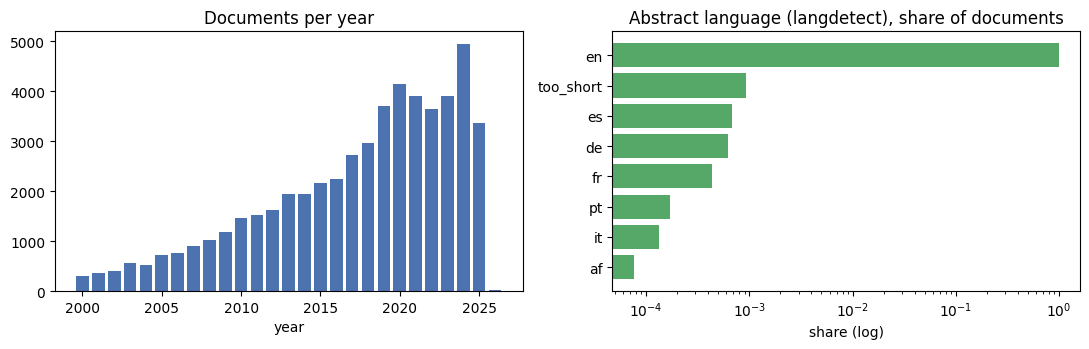

In [7]:
# ============================================================
# FIGURE: DOCUMENTS PER YEAR AND ABSTRACT LANGUAGE (corpus_profile.png / .pdf)
# ============================================================
try:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    ax[0].bar(year.year, year.documents, color="#4C72B0"); ax[0].set_title("Documents per year"); ax[0].set_xlabel("year")
    la_top = la.head(8)
    ax[1].barh(la_top.language[::-1], la_top.share[::-1], color="#55A868"); ax[1].set_xscale("log")
    ax[1].set_title("Abstract language (langdetect), share of documents"); ax[1].set_xlabel("share (log)")
    fig.tight_layout(); fig.savefig(OUT / "corpus_profile.png", dpi=150); fig.savefig(OUT / "corpus_profile.pdf")
    plt.show()
except Exception as exc:
    print("figure skipped:", exc)

In [8]:
# ============================================================
# METADATA AND VALIDATION (metadata.json, validation.json)
# ============================================================
meta.update({"completed_utc": C.now_utc(), "timings_seconds": T.marks, "status": "complete"})
C.write_json(meta, OUT / "metadata.json")
validation = {"gate": "all records parsed into >= 6 fields", "pass": gate_pass,
              "records_with_fewer_than_6_fields": int((recs.n_fields < 6).sum())}
C.write_json(validation, OUT / "validation.json")
print("validation:", validation)
print("timings (s):", T.marks)
written = ["year_distribution.csv", "sources_top40.csv", "language_title.csv", "language_abstract.csv",
           "language_crosstab_title_vs_abstract.csv", "language_abstract_by_period.csv",
           "keyword_language_residue_by_abstract_language.csv", "summary.json", "corpus_profile.png",
           "corpus_profile.pdf", "metadata.json", "validation.json"]
print("files written to", OUT)
for name in written:
    print(f"  {name:55s} {(OUT / name).stat().st_size:>10,} bytes")

validation: {'gate': 'all records parsed into >= 6 fields', 'pass': True, 'records_with_fewer_than_6_fields': 0}
timings (s): {'parse': 5.321, 'langdetect': 207.45}
files written to results/e6_corpus_profile
  year_distribution.csv                                          832 bytes
  sources_top40.csv                                            2,510 bytes
  language_title.csv                                             983 bytes
  language_abstract.csv                                          442 bytes
  language_crosstab_title_vs_abstract.csv                        193 bytes
  language_abstract_by_period.csv                                776 bytes
  keyword_language_residue_by_abstract_language.csv              179 bytes
  summary.json                                                 3,729 bytes
  corpus_profile.png                                          43,512 bytes
  corpus_profile.pdf                                          15,160 bytes
  metadata.json                           